# Computation of one-electron integrals 

In the following section we develop python functions for the efficient calculation of one-electron integrals over Cartesian Gaussian basis functions. We will focus on the overlap integral, which is the simplest of the one-electron integrals, and then we will extend the approach to other types of integrals (kinetic, nuclear attraction, etc.) in subsequent sections. 

In [ ]:
import numpy as np
from numba import njit
@njit(fastmath=True)
def overlap_shell_pair(exp_a: np.ndarray, coeff_a: np.ndarray, norm_a: np.ndarray, center_a: np.ndarray,
                       exp_b: np.ndarray, coeff_b: np.ndarray, norm_b: np.ndarray, center_b: np.ndarray, ijk_lmn: np.ndarray,) -> np.ndarray:
    dim_a = norm_a.shape[1]
    dim_b = norm_b.shape[1]
    out = np.zeros((dim_a, dim_b), dtype=np.float64)

    Dx = center_a[0] - center_b[0]
    Dy = center_a[1] - center_b[1]
    Dz = center_a[2] - center_b[2]
    D2 = Dx * Dx + Dy * Dy + Dz * Dz

    for idx in range(ijk_lmn.shape[0]):
        i, j, k, l, m, n = ijk_lmn[idx]
        ia = idx // dim_b
        ib = idx - ia * dim_b

        val = 0.0
        for pa in range(exp_a.shape[0]):
            alpha_a = exp_a[pa]
            ca = coeff_a[pa] * norm_a[pa, ia]
            for pb in range(exp_b.shape[0]):
                alpha_b = exp_b[pb]
                cb = coeff_b[pb] * norm_b[pb, ib]
                ab_sum = alpha_a + alpha_b
                ab_product = alpha_a * alpha_b
                val += ca * cb * S(i,j,k,l,m,n,Dx,Dy,Dz,D2,ab_sum,ab_product,alpha_a,alpha_b,)
        out[ia, ib] = val

    return out


## How does `overlap_shell_pair` work

This function computes **overlap block** between two Gaussian shells `a` and `b`. Here, Shell `a` contains `dim_a` Cartesian functions and Shell `b` contains `dim_b` Cartesian functions. The result is a matrix `out` of shape `(dim_a, dim_b)`, where each entry is one contracted overlap integral between one function from shell `a` and one from shell `b`. The function is decorated with `@njit(fastmath=True)`, which means that it is compiled with Numba for performance, and it allows for fast math optimizations. The resulting overlap block is used in the assembly of the full AO overlap matrix by inserting it into the appropriate position corresponding to the basis functions of shells `a` and `b`.

Each contracted Cartesian basis function is a linear combination of primitive Gaussians.  
So each overlap element is a **double sum over primitive pairs**:

$$
S_{\mu\nu}^{(ab)}
=
\sum_{p=1}^{N_a}\sum_{q=1}^{N_b}
\Big(d_p^{(a)} N_{p\mu}^{(a)}\Big)
\Big(d_q^{(b)} N_{q\nu}^{(b)}\Big)
\,S_{\text{prim}}(\mu,\nu,p,q),
$$

where:

- $d$ = contraction coefficients (`coeff_a`, `coeff_b`)
- $N$ = primitive normalization factors (`norm_a`, `norm_b`)
- $S_{\text{prim}}$ = primitive Cartesian overlap value (computed by `S(...)`)

The angular powers needed by `S(...)` are taken from `ijk_lmn`.


## Assembly of the full AO overlap matrix
The full AO overlap matrix is assembled by looping over all pairs of shells in the basis set, computing the overlap block for each pair using `overlap_shell_pair`, and inserting it into the appropriate position in the full matrix. The resulting full AO overlap matrix is symmetric, so we only need to compute the lower triangle and then mirror it to the upper triangle.

`overlap_matrix_driver` is the routine that takes all prepacked shell data and assembles the full atomic-orbital overlap matrix in one pass. It starts by allocating a square matrix S_ao with size n_ao x n_ao, where n_ao is the total number of AO basis functions in the molecule. From there, it loops over a list of shell-pair indices. At each loop step p, it reads the two shell ids a = pair_a[p] and b = pair_b[p]. These two arrays already encode which shell pairs must be evaluated.

To place a shell block into the global matrix, the function uses offsets. For shell a, the AO rows are a0:a1 with a0 = offsets[a] and a1 = offsets[a+1]; for shell b, the AO columns are b0:b1. 

The actual numerical block is computed by calling overlap_shell_pair(...). That call receives all data belonging to shell a and shell b—primitive exponents, contraction coefficients, normalization factors, centers, and the angular-index table for this specific pair (ijk_data[p]). The returned block has exactly the shape needed for insertion: (a1-a0, b1-b0). The driver writes it into S_ao[a0:a1, b0:b1].

Because overlap matrices are symmetric, the function does not recompute the transposed block. If a != b, it simply mirrors the result by assigning block.T into the opposite position S_ao[b0:b1, a0:a1]. 

The @njit(fastmath=True) decorator means this whole assembly loop is compiled by Numba to machine code. This removes Python-loop overhead during matrix assembly and lets the driver run at compiled speed while repeatedly calling the compiled shell kernel. 

In [ ]:
@njit(fastmath=True)
def overlap_matrix_driver(n_ao: int, pair_a: np.ndarray, pair_b: np.ndarray, 
                          offsets: np.ndarray, exp_data, coeff_data, norm_data, center_data, ijk_data,) -> np.ndarray:
    S_ao = np.zeros((n_ao, n_ao), dtype=np.float64)

    for p in range(pair_a.shape[0]):
        a = pair_a[p]
        b = pair_b[p]

        a0 = offsets[a]
        a1 = offsets[a + 1]
        b0 = offsets[b]
        b1 = offsets[b + 1]

        block = overlap_shell_pair(exp_data[a],coeff_data[a],norm_data[a],center_data[a],
                                   exp_data[b],coeff_data[b],norm_data[b],center_data[b],ijk_data[p])

        S_ao[a0:a1, b0:b1] = block
        if a != b:
            S_ao[b0:b1, a0:a1] = block.T

    return S_ao
    

## Kinetic energy and nuclear attraction integrals

Both the kinetic as well as the nuclear attraction integrals can be computed by a similar procedure, but with a different shell-pair kernel. The kinetic energy kernel is `kinetic_shell_pair`, which computes the kinetic energy block for a given shell pair. The nuclear attraction kernel is `nuclear_attraction_shell_pair`, which computes the nuclear attraction block for a given shell pair and a set of nuclear coordinates and charges. The assembly of the full kinetic energy and nuclear attraction matrices is done by similar driver functions, `kinetic_matrix_driver` and `nuclear_attraction_matrix_driver`, which call the respective shell-pair kernels in a loop over all shell pairs.

The main difference appears for the nuclear attraction integrals, which require additional input of nuclear coordinates and charges. The `nuclear_attraction_matrix_driver` function takes these as additional arguments and passes them to the `nuclear_attraction_shell_pair` kernel, which uses them to compute the nuclear attraction integrals for each shell pair. In addition, the nuclear attraction integrals require the evaluation of the Boys function, which is a special function that arises in the computation of these integrals. 

### Numerical evaluation of the Boys function

The Boys function appears in the evaluation of nuclear attraction integrals in the following form:

$$
F_n(t)=\int_0^1 x^{2n} e^{-t x^2},dx ,
$$

where $n$ is a non-negative integer and $t\ge 0$. 

For the numerical implementation of the Boys function, the routine uses two different numerical strategies:

1. for very small $t$, a Taylor expansion of the exponential is used;
2. for larger $t$, $F_0(t)$ is evaluated using the error function, and higher orders $F_n(t)$ are obtained by upward recurrence.


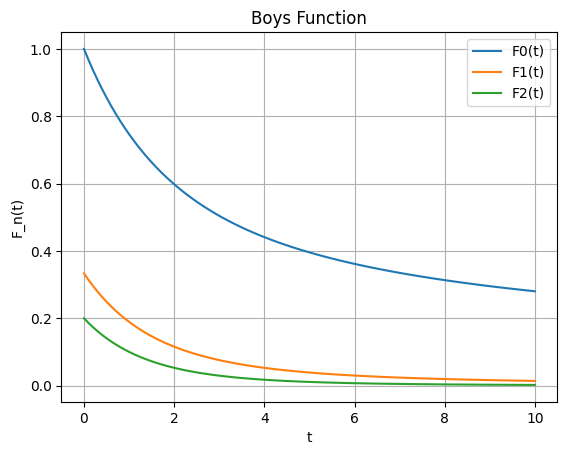

In [4]:
import numpy as np
from numba import njit
import math
@njit(cache=True, fastmath=True)
def Boys(n, t):
    if t < 1e-8:
        # F_n(t) small-t series
        s = 0.0
        term_t = 1.0
        factorial = 1.0
        sign = 1.0
        for k in range(8):
            if k > 0:
                term_t *= t
                factorial *= k
                sign = -sign
            s += sign * term_t / (factorial * (2 * n + 2 * k + 1))
        return s

    root_t = np.sqrt(t)
    exp_t = np.exp(-t)
    inv2t = 0.5 / t
    f = 0.5 * np.sqrt(np.pi) * math.erf(root_t) / root_t
    if n == 0:
        return f

    for m in range(1, n + 1):
        f = ((2 * m - 1) * f - exp_t) * inv2t
    return f

t = np.linspace(0, 10, 100)
F0 = np.array([Boys(0, x) for x in t])
F1 = np.array([Boys(1, x) for x in t])
F2 = np.array([Boys(2, x) for x in t])  

from matplotlib import pyplot as plt
plt.plot(t, F0, label='F0(t)')
plt.plot(t, F1, label='F1(t)')
plt.plot(t, F2, label='F2(t)')
plt.xlabel('t')
plt.ylabel('F_n(t)')
plt.title('Boys Function')
plt.legend()
plt.grid()
plt.show()


### Small-(t) expansion

For very small values of $t$, the exponential function can be expanded as

$$
e^{-t x^2}
=
\sum_{k=0}^{\infty}
\frac{(-t x^2)^k}{k!}.
$$

Substitution into the definition of the Boys function gives

$$
F_n(t)
=
\int_0^1 x^{2n}
\sum_{k=0}^{\infty}
\frac{(-t)^k x^{2k}}{k!}
,dx .
$$

Interchanging summation and integration yields

$$
F_n(t)
=
\sum_{k=0}^{\infty}
\frac{(-t)^k}{k!}
\int_0^1 x^{2n+2k},dx .
$$

The remaining integrals can be evaluated in closed form:

$$
\int_0^1 x^{2n+2k},dx
=
\frac{1}{2n+2k+1}.
$$

Therefore,

$$
F_n(t)
=
\sum_{k=0}^{\infty}
\frac{(-t)^k}{k!(2n+2k+1)} .
$$

The code evaluates the first eight terms of this series:

$$
F_n(t)
\approx
\sum_{k=0}^{7}
\frac{(-t)^k}{k!(2n+2k+1)} .
$$

Explicitly, this is given by

$$
F_n(t)
\approx
\frac{1}{2n+1}
-

\frac{t}{1!(2n+3)}
+
\frac{t^2}{2!(2n+5)}
-

\frac{t^3}{3!(2n+7)}
+\cdots .
$$

This expression also gives the exact limiting value at (t=0):

$$
F_n(0)
=\frac{1}{2n+1}.
$$

The corresponding part of the routine is

```python
if t < 1e-8:
    s = 0.0
    term_t = 1.0
    factorial = 1.0
    sign = 1.0
    for k in range(8):
        if k > 0:
            term_t *= t
            factorial *= k
            sign = -sign
        s += sign * term_t / (factorial * (2 * n + 2 * k + 1))
    return s
```

Here `term_t` stores (t^k), `factorial` stores (k!), and `sign` alternates between (+1) and (-1). Thus the quantity added in each iteration is

$$
\frac{(-1)^k t^k}{k!(2n+2k+1)}.
$$

This branch is used only for $t<10^{-8}$. In this range, the truncated Taylor series is very accurate, and it avoids numerical instabilities caused by division by small $t$ in the recurrence relation used later.





## Evaluation of $F_0(t)$

For $t\ge 10^{-8}$, the routine first evaluates $F_0(t)$. For $n=0$, the

$$
F_0(t)
=
\int_0^1 e^{-t x^2},dx .
$$

Introducing the substitution

$$
u=\sqrt{t}x,
\qquad
dx=\frac{du}{\sqrt{t}} .
$$

The integration limits transform as

$$
x=0 \Rightarrow u=0,
\qquad
x=1 \Rightarrow u=\sqrt{t}.
$$

Hence

$$
F_0(t)
=

\frac{1}{\sqrt{t}}
\int_0^{\sqrt{t}} e^{-u^2},du .
$$

The error function is defined by

$$
\operatorname{erf}(z)
=
\frac{2}{\sqrt{\pi}}
\int_0^z e^{-u^2},du .
$$

Therefore,

$$
\int_0^{\sqrt{t}} e^{-u^2},du
=
\frac{\sqrt{\pi}}{2}
\operatorname{erf}(\sqrt{t}).
$$

Thus,

$$
F_0(t)
=
\frac{\sqrt{\pi}}{2\sqrt{t}}
\operatorname{erf}(\sqrt{t}) .
$$

This is implemented as

```python
root_t = np.sqrt(t)
exp_t = np.exp(-t)
inv2t = 0.5 / t
f = 0.5 * np.sqrt(np.pi) * math.erf(root_t) / root_t
```

After this line, the variable `f` contains $(F_0(t))$. If the requested order is $n=0$, the routine returns this value directly:

```python
if n == 0:
    return f
```


## Recurrence relation for higher Boys functions

For $n>0$, higher Boys functions can be generated from $F_0(t)$ using an upward recurrence relation. The recurrence relation is

$$
F_m(t)
=
\frac{(2m-1)F_{m-1}(t)-e^{-t}}{2t}.
$$

It can be derived by differentiating the product

$$
x^{2m-1}e^{-t x^2}.
$$

Using the product rule, one obtains

$$
\frac{d}{dx}
\left(
x^{2m-1}e^{-t x^2}
\right)
=
(2m-1)x^{2m-2}e^{-t x^2}
-
2t x^{2m}e^{-t x^2}.
$$

Integrating from $0$ to $1$ gives

$$
\int_0^1
\frac{d}{dx}
\left(
x^{2m-1}e^{-t x^2}
\right)
\,dx
=
(2m-1)
\int_0^1 x^{2m-2}e^{-t x^2}\,dx
-
2t
\int_0^1 x^{2m}e^{-t x^2}\,dx .
$$

The left-hand side is the boundary term

$$
\left[
x^{2m-1}e^{-t x^2}
\right]_0^1
=
e^{-t}.
$$

The two integrals on the right-hand side are Boys functions:

$$
\int_0^1 x^{2m-2}e^{-t x^2}\,dx
=
F_{m-1}(t),
$$

and

$$
\int_0^1 x^{2m}e^{-t x^2}\,dx
=
F_m(t).
$$

Therefore,

$$
e^{-t}
=
(2m-1)F_{m-1}(t)
-
2tF_m(t).
$$

Solving for $F_m(t)$ gives

$$
F_m(t)
=
\frac{(2m-1)F_{m-1}(t)-e^{-t}}{2t}.
$$

This is the recurrence implemented in the loop:

```python
for m in range(1, n + 1):
    f = ((2 * m - 1) * f - exp_t) * inv2t
return f
```

The variable `f` is updated successively:

$$
F_0(t)
\rightarrow
F_1(t)
\rightarrow
F_2(t)
\rightarrow
\cdots
\rightarrow
F_n(t).
$$

For example, the first step gives

$$
F_1(t)
=
\frac{F_0(t)-e^{-t}}{2t},
$$

the second step gives

$$
F_2(t)
=
\frac{3F_1(t)-e^{-t}}{2t},
$$

and so on.



## Numerical motivation

The Taylor expansion is used near $t=0$ because the recurrence relation contains a division by $t$. Moreover, the numerator

$$
(2m-1)F_{m-1}(t)-e^{-t}
$$

can suffer from cancellation when $t$ is very small. The small-$t$ series avoids this problem.

For larger $t$, the error-function expression for $F_0(t)$ is efficient and accurate. The recurrence relation then provides a cheap way to compute higher-order Boys functions without evaluating separate integrals or incomplete gamma functions.

Thus, the code implements a standard hybrid strategy:

$$
\boxed{
\text{small }t: \text{Taylor series}
\qquad
\text{larger }t: F_0(t) \text{ from erf, then upward recurrence}
}
$$

This strategy is simple and efficient for low and moderate values of $n$, as typically needed in basic Gaussian integral implementations. For very large angular momentum, more elaborate integral codes may use downward recurrence, interpolation, or asymptotic expansions to improve numerical stability.